In [6]:
# Classification

from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix

X , y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=43)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
classifier = LogisticRegression()
classifier.fit(X_train_scaled, y_train)
X_test_scaled = scaler.transform(X_test)

y_train_pred = classifier.predict(X_train_scaled)
print("y_train_pred",y_train_pred[:10])

y_test_pred = classifier.predict(X_test_scaled)
print("y_test_pred",y_test_pred[:10])

y_train_pred [1 0 1 1 1 0 0 1 1 0]
y_test_pred [1 1 0 0 0 1 1 1 0 0]


In [7]:
# train set

#acc
print("===Train set===")
acc = accuracy_score(y_train, y_train_pred)
print("Train Accuracy:", acc)
f1_scr = f1_score(y_train, y_train_pred)
print("F1 score: ",f1_scr)
prec= precision_score(y_train, y_train_pred)
print("Precision",prec)
recall = recall_score(y_train, y_train_pred)
print("recall", recall)

y_train_proba = classifier.predict_proba(X_train_scaled)[:, 1]

roc_auc = roc_auc_score(y_train, y_train_proba)
print("roc_auc",roc_auc)

# test set

print("===Test set===")
acc_test = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", acc_test)
f1_scr_test = f1_score(y_test, y_test_pred)
print("f1 test score", f1_scr_test)
prec_test = precision_score(y_test, y_test_pred)
print("test precision", prec_test)
recall_test = recall_score(y_test, y_test_pred)
print("recall test",recall_test)

y_test_proba = classifier.predict_proba(X_test_scaled)[:,1]
roc_auc_test = roc_auc_score(y_test, y_test_proba)
print("roc auc test",roc_auc_test)

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

===Train set===
Train Accuracy: 0.989010989010989
F1 score:  0.9911504424778761
Precision 0.9893992932862191
recall 0.9929078014184397
roc_auc 0.998995613495675
===Test set===
Test Accuracy: 0.9736842105263158
f1 test score 0.9801324503311258
test precision 0.9736842105263158
recall test 0.9866666666666667
roc auc test 0.9863247863247864
Confusion Matrix:
 [[37  2]
 [ 1 74]]


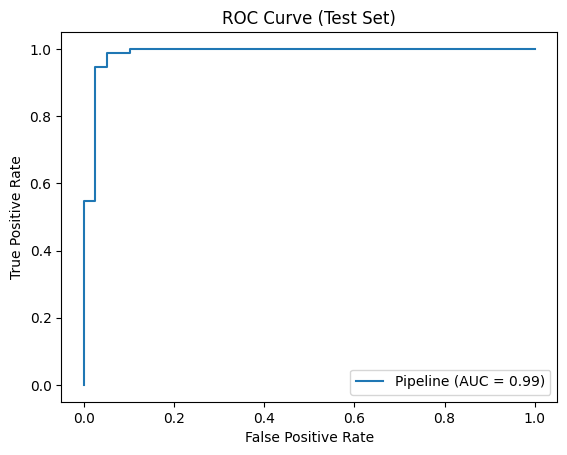

In [23]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

# Plot
plt.figure()

plt.plot(fpr, tpr, label="Pipeline (AUC = {0:.2f})".format(roc_auc_test))

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()

with open("w2_day4_ex4_q3.png", "wb") as f:
    plt.savefig(f)
plt.show()